# Project: FoodHub Data Analysis


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Library to suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# let colab access my google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir('/content/drive/MyDrive/Colab Notebooks/Python for Data Science/Food Hub Project')

['foodhub_order.csv', 'FDS_Project_LearnerNotebook_FullCode.ipynb']

In [ ]:
# read the data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Python for Data Science/Food Hub Project/foodhub_order.csv')

# first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### Rows and columns

In [ ]:
df.shape

(1898, 9)

#### Observations:
The data contains 1898 rows and 9 columns.


### Datatypes of the different columns in the dataset

In [ ]:
# Use info() to print a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
Among the nine columns in the dataset, five are numerical variables; four stored as int64 and one as float64:
* integer datatype
  * order_id
  * customer_id
  * food_preparation_time
  * delivery_time

* float datatype
  * cost_of_the_order

The other four columns are categorical variables, stored as object:
* object datatype
  * restaurant_name
  * cuisine_type
  * day_of_the_week
  * rating

It is worth noting that the rating column, although expected to hold integer values, is stored as an object.

Also, the dataset contains no null values across all columns.

### Missing values in the data

In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


In [ ]:
df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


#### Observations:
- The dataset contains no formal missing values across any column.

- However, the rating field includes 736 entries labeled as “Not given”, which represent unrated orders.

To properly process this variable, it is appropriate to:

  * Replace “Not given” with NaN so it is recognized as missing data.
  * Convert the rating column to a numeric datatype.
  * Impute the missing values later if needed, using a suitable method.

This is to ensure accurate analysis and flexibility for appropriate imputation in later steps, as need be.


In [ ]:
# Replace "Not given" entries with missing values (NaN) in the rating column
df['rating'] = df['rating'].replace('Not given', np.nan)

# Convert the rating column to numeric (float)
df['rating'] = df['rating'].astype(float)

### Statistical summary of the data

In [ ]:
df.describe()

,order_id,customer_id,cost_of_the_order,rating,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1162.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,4.344234,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,0.741478,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,3.000000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,4.000000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,5.000000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,5.000000,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,5.000000,35.000000,33.000000


#### Observations:
Food preparation times after an order is placed are as follows:
* minimum time: 20 minutes
* average time: about 27 minutes
* maximum time: 35 minutes



### Orders are not rated

In [ ]:
df['rating'].value_counts(dropna = False)

,count
rating,
NaN,736
5.0,588
4.0,386
3.0,188


#### Observations:
There are 736 unrated orders in the dataset.

Additionally, all recorded ratings are within the range of 3–5, with no occurrences of 0, 1, or 2 ratings.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

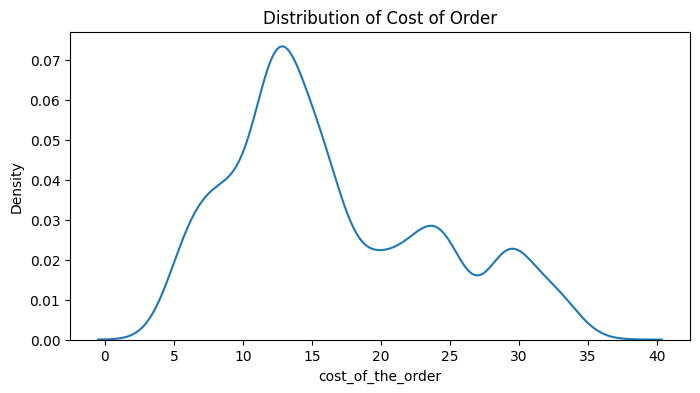

In [ ]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='cost_of_the_order')
plt.title('Distribution of Cost of Order')
plt.show()

- The distribution of cost is right-skewed, with most meals priced between \$8 and \$18 .
- A small number of orders exceed \$30, showing the presence of premium-priced items.

Since ratings are mostly positive, restaurants might appear better than they are. FoodHub should encourage user ratings, e.g., via reward points or prompts after delivery, to obtain a more accurate service assessment.

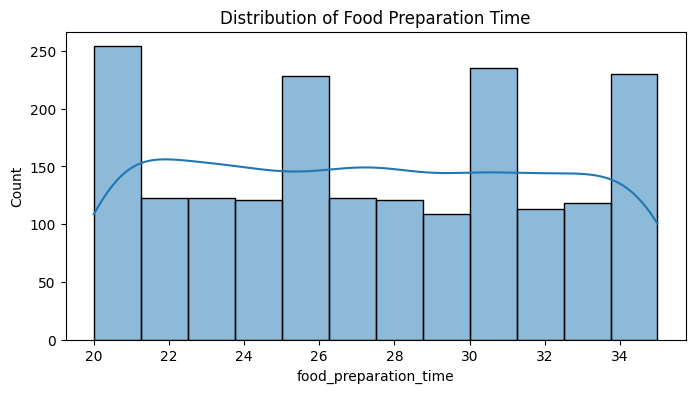

Text(0.5, 0, 'food_preparation_time')

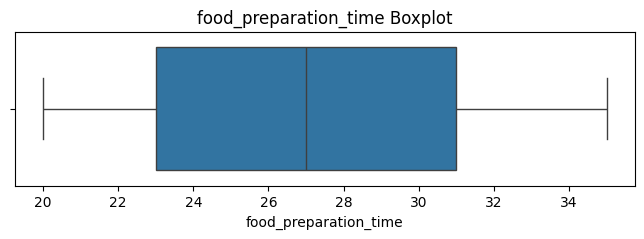

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='food_preparation_time', kde = True)
plt.title('Distribution of Food Preparation Time')
plt.show()

plt.figure(figsize=(8, 2))
sns.boxplot(x=df['food_preparation_time'])
plt.title('food_preparation_time Boxplot')
plt.xlabel('food_preparation_time')

- Food preparation times range roughly from 20 to 35 minutes, with a median around 27 minutes.
- There are no outliers, indicating that while prep times vary moderately, restaurants are reasonably consistent in how long they take to prepare food.
- Therefore, possible operational bottleneck is not due to preparation, but delivery logistics.

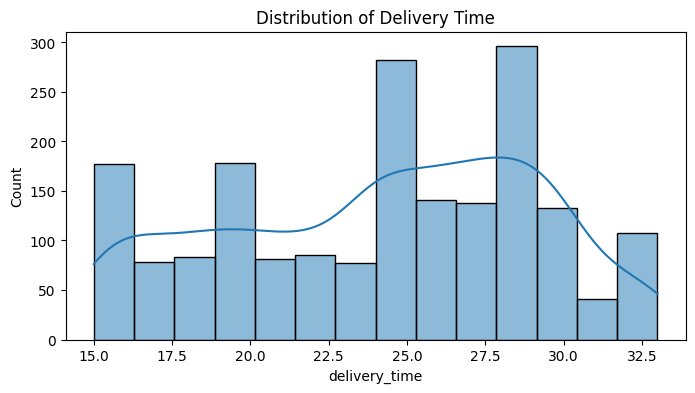

Text(0.5, 0, 'delivery_time')

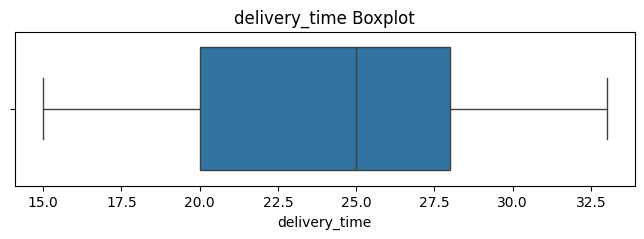

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='delivery_time', kde = True)
plt.title('Distribution of Delivery Time')
plt.show()

plt.figure(figsize=(8, 2))
sns.boxplot(x=df['delivery_time'])
plt.title('delivery_time Boxplot')
plt.xlabel('delivery_time')

- Delivery time varies more than prep time, ranging roughly from 15 to 33 minutes.

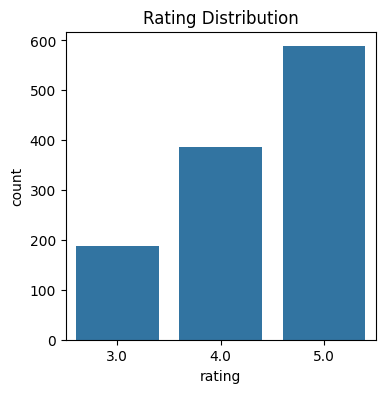

In [ ]:
plt.figure(figsize=(4, 4))
sns.countplot(data=df, x='rating')
plt.title('Rating Distribution')
plt.show()

- Majority of ratings lie between 4 and 5, with no ratings below 3 and 736 orders unrated .
- This indicates a generally satisfied customer base, but the large number of missing ratings suggests that many customers do not provide feedback.


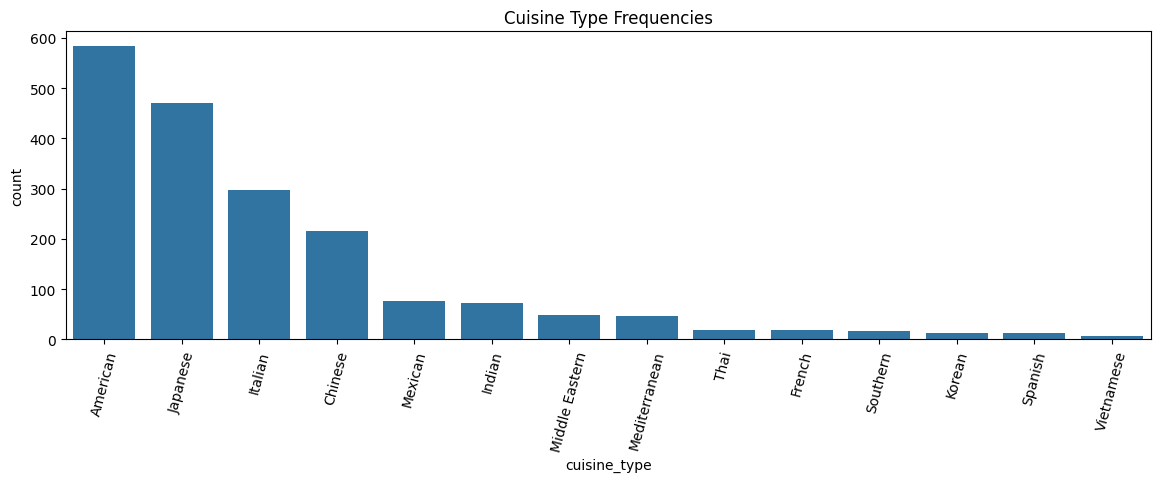

In [ ]:
plt.figure(figsize=(14, 4))
sns.countplot(data=df, x='cuisine_type', order=df['cuisine_type'].value_counts().index)
plt.xticks(rotation=75)
plt.title('Cuisine Type Frequencies')
plt.show()


- American cuisine dominates the dataset, followed by Japanese and Italian,
while cuisines like Korean, Spanish, and Vietnamese appear rarely .
- This could generally imply that the platform is driven by popular fast-moving cuisines, but niche cuisines present opportunities for specialized marketing, offering more variety to increase customer interest.

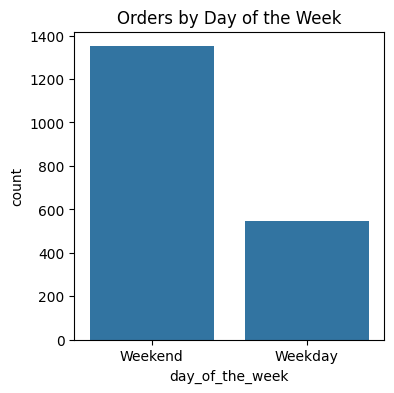

In [ ]:
plt.figure(figsize=(4, 4))
sns.countplot(data=df, x='day_of_the_week')
plt.title('Orders by Day of the Week')
plt.show()


- Orders are noticeably higher on weekends than weekdays .
- Since FoodHub demand spikes on weekends, this could suggest that it should increase delivery staff availability on weekends to reduce delays and improve customer experience.

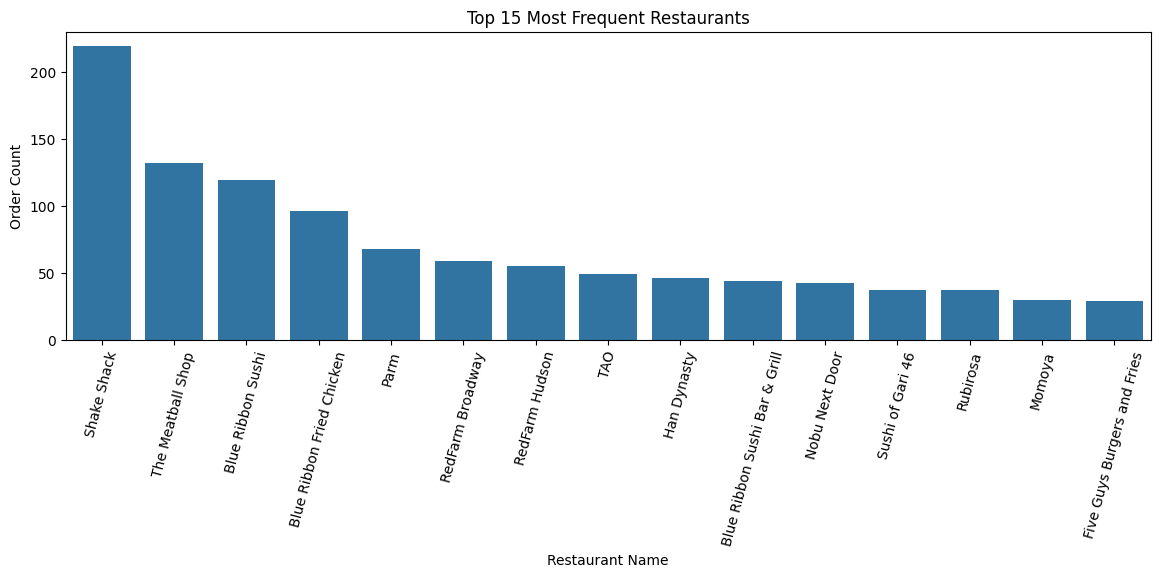

In [ ]:
top_restaurants = df['restaurant_name'].value_counts().head(15)

plt.figure(figsize=(14, 4))
sns.barplot(x=top_restaurants.index, y=top_restaurants.values)
plt.xticks(rotation=75)
plt.xlabel('Restaurant Name')
plt.ylabel('Order Count')
plt.title('Top 15 Most Frequent Restaurants')
plt.show()


- A small number of restaurants (e.g., Shake Shack, The Meatball Shop, Blue Ribbon Sushi) receive a large share of orders (over 100), while most have very few.
- This suggests that the market is highly concentrated.
- As such, ppartnerships with top-ordered restaurants may drive sales.
- However, promoting lower-visibility restaurants through offers or visibility boosts can balance demand and diversify earnings.

### Top 5 restaurants in terms of the number of orders received

In [ ]:
df['restaurant_name'].value_counts().head()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
The top five restaurants with the highest number of orders are:
* **Shake Shack** (219 orders)
* **The Meatball Shop** (132 orders)
* **Blue Ribbon Sushi** (119 orders)
* **Blue Ribbon Fried Chicken** (96 orders)
* **Parm** (68 orders)


### The most popular cuisine on weekends

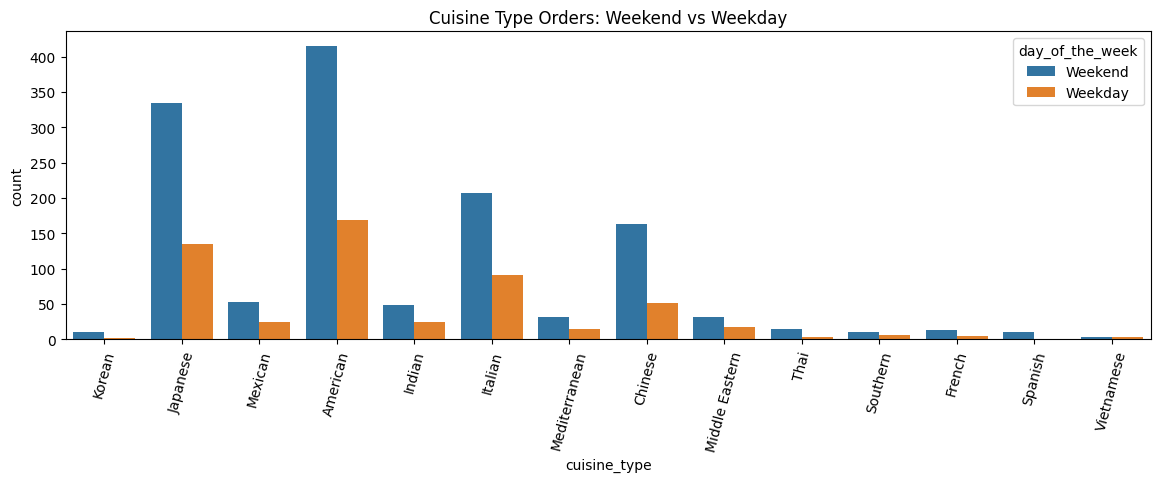

In [ ]:
plt.figure(figsize=(14, 4))
sns.countplot(data = df, x = 'cuisine_type', hue = 'day_of_the_week')
plt.xticks(rotation = 75)
plt.title('Cuisine Type Orders: Weekend vs Weekday')
plt.show()

#### Observations:
American cuisine records the highest number of weekend orders.

Also, across all cuisine types, order volumes are consistently higher on weekends compared to weekdays.


### Percentage of the orders that cost more than 20 dollars

In [ ]:
df[df['cost_of_the_order'] > 20].shape[0]

555

In [ ]:
df[df['cost_of_the_order'] > 20].shape[0] / df.shape[0] * 100

29.24130663856691

#### Observations:

Out of the 1,898 orders, 555 cost more than 20 dollars, representing about 29.24% of all orders.


### Mean order delivery time

In [ ]:
df['delivery_time'].mean()

np.float64(24.161749209694417)

#### Observations:

On average, food orders are delivered in about 24 minutes.


### The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Here are the IDs of these customers and the number of orders they placed:

In [ ]:
df['customer_id'].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:
The most active customer is 52832, placing 13 orders, while customers 47440 and 83287 follow with 10 and 9 orders, respectively.

| Customer ID | Number of Orders |
|-------------|------------------|
| 52832       | 13               |
| 47440       | 10               |
| 83287       | 9                |



### Multivariate Analysis

In [ ]:
corr_matrix = df.select_dtypes(include = 'number').corr()

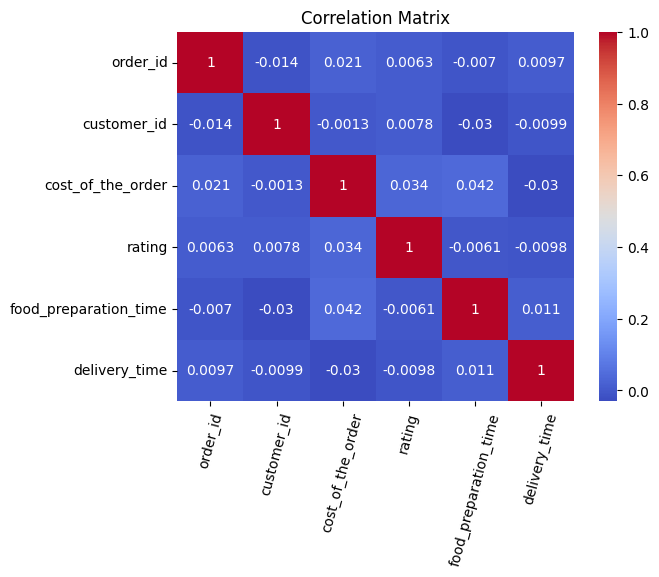

In [ ]:
# Find the smallest correlation value among all numerical features
min_corr = corr_matrix.min().min()

sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', vmin = min_corr,vmax = 1)
plt.title('Correlation Matrix')
plt.xticks(rotation = 75)
plt.show()


#### Observations:
There is no strong linear relationship between any pair of numerical variables in the dataset since all correlation values are very close to 0.
This indicates that:

- Order IDs and Customer IDs do not relate to cost, preparation time, or delivery time (as expected, since they are identifiers).

- The cost of an order has very weak or almost no linear relationship with how long it takes to prepare or deliver. This presents an opportunity for priority preperation and delivery upsell to FoodHub.

- Food preparation time and delivery time are also nearly uncorrelated, suggesting that longer preparation does not necessarily mean longer delivery.

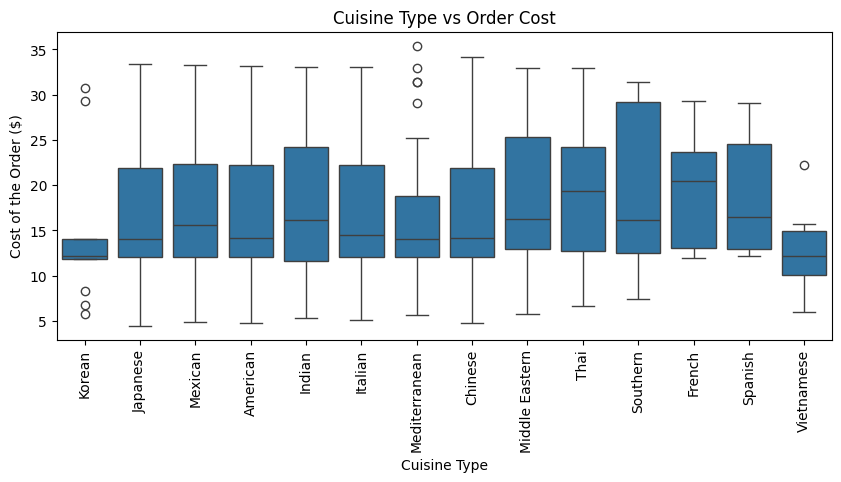

In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='cuisine_type', y='cost_of_the_order')
plt.xticks(rotation=90)
plt.xlabel('Cuisine Type')
plt.ylabel('Cost of the Order ($)')
plt.title('Cuisine Type vs Order Cost')
plt.show()

#### Observations: Cuisine Type vs Order Cost

- There is noticeable variation in cost across cuisine types. Cuisines such as French and Thai show higher median prices, while Korean and Vietnamese tend to be cheaper on average.
- Some cuisines (e.g., Indian, Southern, Mediterranean) have higher variability and more outliers, indicating that these restaurants offer a wider range of prices.

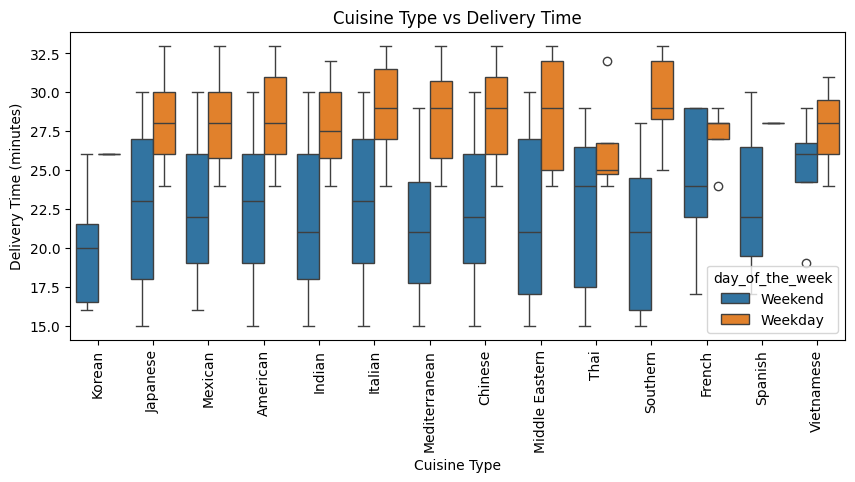

In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='cuisine_type', y='delivery_time', hue = 'day_of_the_week')
plt.xticks(rotation=90)
plt.xlabel('Cuisine Type')
plt.ylabel('Delivery Time (minutes)')
plt.title('Cuisine Type vs Delivery Time')
plt.show()


#### Observations: Cuisine Type vs Delivery Time

- Delivery times vary across cuisines.
- Weekday deliveries are consistently slower than weekend deliveries for most cuisines. This could imply rush hour travel congestion, and optimizing driver deployment around traffic patterns could be a solution.
- Generally, day of the week appears to influence delivery time, with weekend deliveries generally quicker.

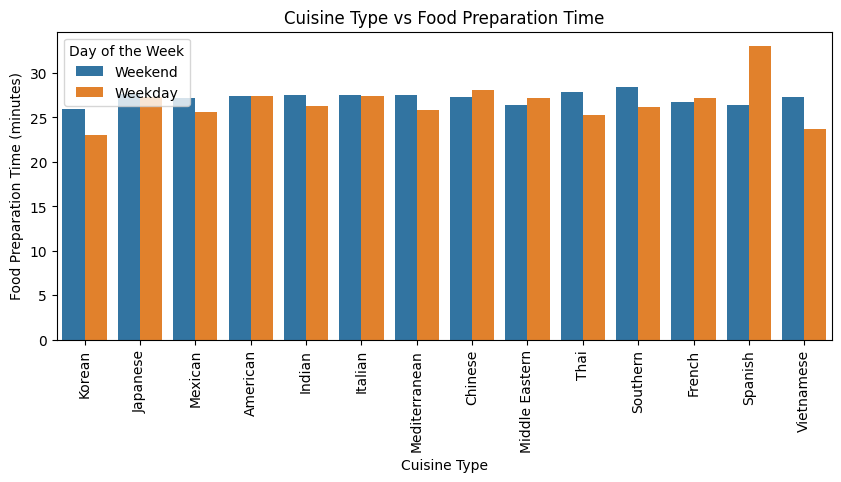

In [ ]:
plt.figure(figsize=(10, 4))
sns.barplot(data=df, x='cuisine_type', y='food_preparation_time', errorbar=None, hue = 'day_of_the_week')
plt.xticks(rotation=90)
plt.xlabel('Cuisine Type')
plt.ylabel('Food Preparation Time (minutes)')
plt.title('Cuisine Type vs Food Preparation Time')
plt.legend(title='Day of the Week')
plt.show()

#### Observations: Cuisine Type vs Food Preparation Time

- Food preparation times are fairly consistent over the week, across all cuisines.
- Weekend preparation times are slightly higher for most cuisines, suggesting increased kitchen load or slower operations during weekends.
- Spanish cuisine shows a notably  clear gap in preparation time between weekdays and weekends, with weekday preparation taking considerably longer than weekend preparation.

Overall, cuisine type has a very slight influence on the preparation speed, and the differences are not extreme.

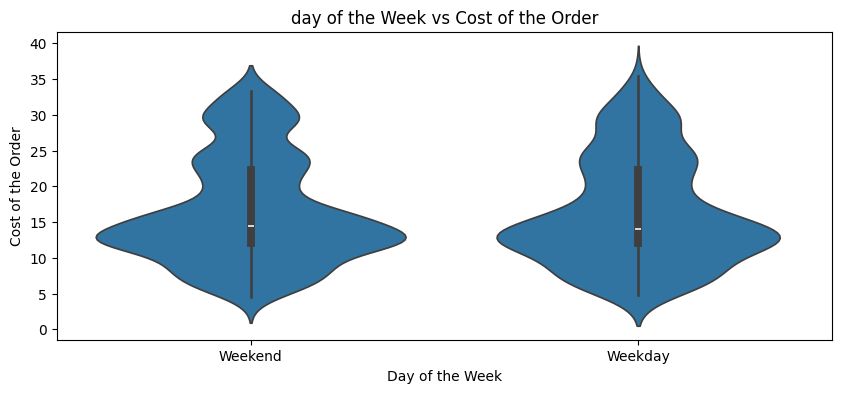

In [ ]:
plt.figure(figsize=(10, 4))
sns.violinplot(data=df, x='day_of_the_week', y='cost_of_the_order')
plt.xlabel('Day of the Week')
plt.ylabel('Cost of the Order')
plt.title('day of the Week vs Cost of the Order')
plt.show()

#### Observations: Day of the Week vs Cost of the Order

- The cost distribution shapes for weekends and weekdays are very similar, indicating no major price changes based on day of the week.
- In both cases, most orders fall between \$8 and \$18, with a small number of high-priced orders up to $30+.
- There are more high-priced outliers during weekdays, hinting that expensive orders are more frequent during weekdays.

In general, order cost is not significantly affected by the day of the week, unlike delivery.


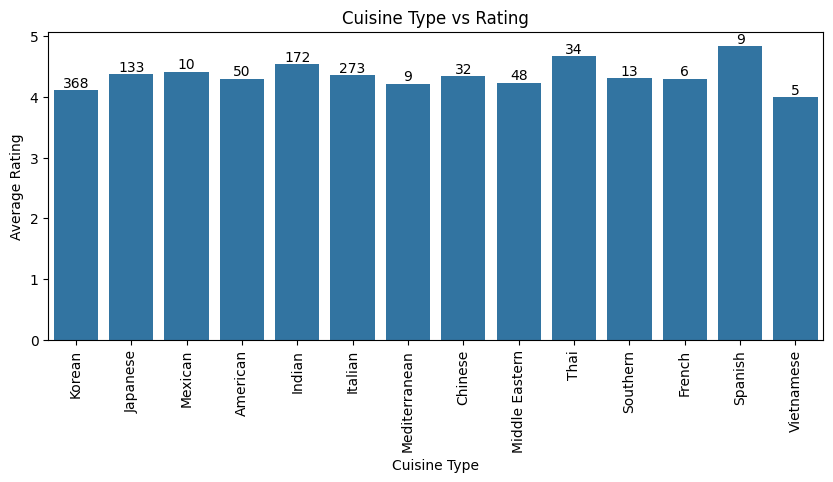

In [ ]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(data=df, x='cuisine_type', y='rating', errorbar=None, estimator=lambda x: x.mean())

# Count how many ratings each cuisine has
counts = df.groupby('cuisine_type')['rating'].count()

# Add annotations (number of ratings)
for i, bar in enumerate(ax.patches):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        counts[i],
        ha='center', va='bottom', fontsize=10, color='black'
    )

plt.xticks(rotation=90)
plt.xlabel('Cuisine Type')
plt.ylabel('Average Rating')
plt.title('Cuisine Type vs Rating')
plt.show()


#### Observations: Cuisine Type vs Rating
- Based on the available (non-imputed) ratings, all the cuisine types score above 4 on average, creating positive skew. However, the reliability of these averages varies significantly across cuisines.
- Spanish cuisine appears to have the highest average rating, though this is based on only 9 reviews. As such, its high rating may not be reliable.
- Korean cuisine has the most ratings (368), whereas Vietnamese has the fewest (5 reviews).

- Missing ratings (737 unrated orders) are NOT random; likely happy customers do not rate, while unhappy ones rate less frequently.
- To reduce rating bias, FoodHub should nudge customers with unrated orders for feedback.

In [ ]:

# Compare total orders vs. orders without ratings for each cuisine
cuisine_rating_stats = pd.DataFrame({
    'unrated_orders': df[df['rating'].isnull()]['cuisine_type'].value_counts(),
    'total_orders': df['cuisine_type'].value_counts()
})

# Calculate the percentage of unrated orders for each cuisine
cuisine_rating_stats['unrated_percentage'] = (
    cuisine_rating_stats['unrated_orders'] / cuisine_rating_stats['total_orders'] * 100
)

cuisine_rating_stats.sort_values(by = 'unrated_percentage', ascending = False)


,unrated_orders,total_orders,unrated_percentage
cuisine_type,,,
Thai,10,19,52.631579
Spanish,6,12,50.000000
French,8,18,44.444444
Italian,126,298,42.281879
Japanese,197,470,41.914894
Chinese,82,215,38.139535
Mexican,29,77,37.662338
American,216,584,36.986301
Indian,23,73,31.506849


- Thai and Spanish cuisines have the highest proportion of unrated orders, with over half of their orders lacking customer feedback.
- While these cuisines appear to receive relatively high average ratings, the limited number of reviews makes their perceived popularity less reliable than other cuisines with more consistent feedback.
- FoodHub should introduce targeted rating incentives (such as reward points or coupons) for cuisines with low rating engagement to ensure FoodHub’s recommendations and promotional decisions reflect genuine customer sentiment rather than incomplete data.

### The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Here are the restaurants fulfilling the criteria to get the promotional offer:

In [ ]:
counts = df.groupby('restaurant_name')['rating'].count()
means = df.groupby('restaurant_name')['rating'].mean()
list(counts[(counts > 50) & (means > 4)].index)

['Blue Ribbon Fried Chicken',
 'Blue Ribbon Sushi',
 'Shake Shack',
 'The Meatball Shop']

#### Observations:
Before imputing missing ratings, only four restaurants qualify for the promotion:
* Blue Ribbon Fried Chicken
* Blue Ribbon Sushi
* Shake Shack
* The Meatball Shop

Evaluating eligibility prior to imputation ensures that both average ratings and rating counts are based solely on actual customer reviews.

In [ ]:
# New copy with imputed values
df_imputed = df.copy()

df_imputed['rating'] = df_imputed['rating'].fillna(
    df_imputed.groupby('restaurant_name')['rating']
    .transform('mean')
    .round()
)

In [ ]:
df_imputed['rating'].isnull().sum()

np.int64(30)

#### Observations:
Imputing missing ratings using the rounded mean rating of the respective restaurant successfully fills most gaps, but **30 values remain missing**. These correspond to restaurants with no existing ratings, making their averages impossible to compute. Consequently, a secondary method must be applied to complete the imputation for these cases.

In [ ]:
df_imputed['rating'] = df_imputed['rating'].fillna(
    df_imputed.groupby('cuisine_type')['rating']
    .transform('mean')
    .round()
)


In [ ]:
df_imputed['rating'].isnull().sum()

np.int64(0)

#### Observations:
Imputing the remaining ratings with the average rating of their respective cuisine type completes the process, and the dataset no longer contains any missing rating values.

In [ ]:
count_imputed = df_imputed.groupby('restaurant_name')['rating'].count()
means_imputed = df_imputed.groupby('restaurant_name')['rating'].mean()
list(count_imputed[(count_imputed > 50) & (means_imputed > 4)].index)

['Blue Ribbon Fried Chicken',
 'Blue Ribbon Sushi',
 'Parm',
 'RedFarm Broadway',
 'RedFarm Hudson',
 'Shake Shack',
 'The Meatball Shop']

#### Observations:
Following the imputation of missing ratings, the number of restaurants meeting the promotion criteria increases to seven:
* Blue Ribbon Fried Chicken
* Blue Ribbon Sushi
* Parm
* RedFarm Broadway
* RedFarm Hudson
* Shake Shack
* The Meatball Shop

In [ ]:
df_imputed.select_dtypes(include = 'number').corr().loc['rating']

,rating
order_id,0.013719
customer_id,-0.002183
cost_of_the_order,0.031837
rating,1.000000
food_preparation_time,-0.010604
delivery_time,-0.013142


Notice that even after imputing the missing order ratings, there remains no meaningful correlation between ratings and the other numerical variables. The correlation values stay very close to zero, indicating that customers’ ratings are not significantly influenced by preparation time, delivery time, or order cost.

### The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Here is the net revenue generated by the company across all orders:

In [ ]:
# Define a function that computes the company’s revenue for a given order
def calculate_revenue(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0

# Create a column showing the revenue earned from each individual order
df['revenue'] = df['cost_of_the_order'].apply(calculate_revenue)

# Total revenue
df['revenue'].sum()


np.float64(6166.303)

In [ ]:
df[df['cost_of_the_order'] > 20]['revenue'].sum()/df['revenue'].sum()*100

np.float64(59.820730509026234)

#### Observations:
FoodHub generated a total revenue of \$6166.30, and nearly 60% of this revenue comes from high-value orders priced above \$20, even though these orders make up only 29% of total orders.

### The company wants to analyze the total time required to deliver the food. Here is the percentage of orders that take more than 60 minutes to get delivered from the time the order is placed? (Note: The food has to be prepared and then delivered.)

In [ ]:
# Create a new column for the total time from order placement to delivery
df['total_time'] = df['delivery_time'] + df['food_preparation_time']

df['total_time'][df['total_time'] > 60].count() / df['total_time'].count() * 100



np.float64(10.537407797681771)

#### Observations:
Approximately 10.5% of all orders require over an hour to be delivered from the time they are placed.

### The company wants to analyze the delivery time of the orders on weekdays and weekends. Here is how the mean delivery time vary during weekdays and weekends:

In [ ]:
df.groupby('day_of_the_week')['delivery_time'].mean()

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


#### Observations:
Delivery speeds differ by day type: weekday average 28 minutes, while weekend average 22 minutes, showing a noticeable increase of about 6 minutes during weekend.

### Conclusions:
Based on analysis of 1898 customer orders from FoodHub’s platform, several patterns emerged relating to demand, pricing, customer behavior, delivery dynamics, and revenue potential.

These insights highlight profit opportunities, operational gaps, and strategies for brand growth.

*  **Customer demand is weekend-driven:** Over twice as many orders occur on weekends, signaling peak revenue and operational load.

* **Sales are concentrated among a few restaurants:** A small group (e.g., Shake Shack, Meatball Shop) captures a disproportionately high number of orders, suggesting strong brand pull or customer loyalty.

* **High customer satisfaction but low rating participation:** Ratings average above 4, yet 736 orders had no rating, risking unreliable quality perception.

* **No Strong Relationship Between Cost and Delivery/Preparation Time:**
Customers are not paying more for faster delivery or quicker preparation, suggesting that higher prices are driven by cuisine type and restaurant brand, not operational efficiency.

* **Premium orders represent a strong revenue source:** Only 29% of orders are priced above $20 but contribute disproportionately to FoodHub’s revenue model.

* **Average delivery takes 24 minutes and is slower on weekdays:** This operational delay is likely due to staffing differences.

### Recommendations:

1. **Scale Weekend Fleet Capacity**

Increase delivery staffing on weekends to reduce wait times and safeguard high-demand revenue periods.

2. **Strengthen Partnerships With Top Restaurants**

Negotiate featured placements, shared promotions, and exclusive deals with high-order restaurants to maximize growth and retention.

3. **Boost Ratings Participation**

Introduce incentives (such as loyalty points or coupons) for rating completion to improve decision-making data and trustworthiness of reviews.

4. **Promote Mid-Tier and Niche Cuisines**

Use targeted discounts or app visibility boosts to diversify orders beyond concentrated brands and increase diversity and overall ecosystem profitability.

5. **Prioritize Premium-Order Marketing**

Target promotions to high-value customer segments and highlight premium offerings (like curated bundles or “Chef Picks”) to increase >$20 conversions.

6. **Improve Weekday Delivery Efficiency**

Apply weekday operational optimizations (route algorithms, staffing adjustments, batching) to minimize delays and enhance customer satisfaction.

---